# LangGraph 201：构建深度研究代理

在本笔记本中，我们将构建一个多代理研究系统，可以进行全面的网络研究。我们将分三部分逐步构建该系统：

1. **第 1 部分**：执行网络搜索的单一研究人员代理
2. **第 2 部分**：协调多个研究人员的主管代理
3. **第 3 部分**：包含用户说明和报告生成的完整工作流程

 <img src="../../images/deep_research.png" style="width: auto; max-height: 500px; border-radius: 8px;">

## 准备工作：设置

首先，让我们安装依赖项并设置环境。

#### 加载环境变量

In [47]:
import os
from dotenv import load_dotenv

# 加载环境变量
load_dotenv()

# 研究人员所需的 API 密钥
if not os.getenv("DEEPSEEK_API_KEY"):
    raise ValueError('在环境变量中找不到 DEEPSEEK_API_KEY')
if not os.getenv("TAVILY_API_KEY"):
    raise ValueError('在环境变量中找不到 TAVILY_API_KEY')

import sys
from pathlib import Path

project_root = Path().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

#### 导入所需的库

In [48]:
import json
import asyncio
import operator
from datetime import datetime
from typing import Literal, Annotated
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
    filter_messages,
    get_buffer_string,
    MessageLikeRepresentation,
)
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from tavily import TavilyClient
from utils.utils import show_graph

#### 辅助函数

In [49]:
def get_today_str() -> str:
    """获取当前日期的显示格式。"""
    now = datetime.now()
    return f"{now:%a} {now:%b} {now.day}, {now:%Y}"


def openai_websearch_called(response):
    """DeepSeek 模式下不使用 OpenAI 原生网络搜索。"""
    return False

#### 配置

让我们定义我们的硬编码配置。在生产系统中，这些是可配置的，但对于这个教育示例，我们将保持它们简单且可见。

In [50]:
# 型号配置
RESEARCH_MODEL = 'deepseek:deepseek-v4-flash'  # 对这款笔记本的硬性要求
MAX_OUTPUT_TOKENS = 10000

# 研究限制
MAX_RESEARCHER_ITERATIONS = 3  # 主管可以委派多少次
MAX_REACT_TOOL_CALLS = 10  # 每个研究人员的最大工具调用数
MAX_CONCURRENT_RESEARCH_UNITS = 5  # 最大并行研究人员
MAX_STRUCTURED_OUTPUT_RETRIES = 3


# 初始化模型
def get_model():
    return init_chat_model(
        model=RESEARCH_MODEL,
        max_tokens=MAX_OUTPUT_TOKENS,
        api_key=os.getenv("DEEPSEEK_API_KEY"),
    )


print(f"✓ Configuration set: {RESEARCH_MODEL}")

✓ Configuration set: deepseek:deepseek-v4-flash


## 第 1 部分：构建单一研究代理

我们将从构建一个单一的研究代理开始，它可以：
1. 获得研究课题
2.使用 Tavily 网络搜索收集信息
3. 将调查结果压缩成摘要

 <img src="../../images/researcher.png" style="width: auto; max-height: 500px; border-radius: 8px;">

### 1.1 定义状态

信息如何通过这些步骤流动？  

状态是我们将介绍的第一个 LangGraph 概念。 **State可以被认为是代理的内存 - 它是在图的节点之间传递的共享数据结构**，代表应用程序的当前快照。 

对于我们的研究人员，我们将定义 3 个要跟踪的字段：对话历史记录、主题以及已进行的 API 调用次数。 

我们还可以定义特定的输出状态来指示我们期望研究人员返回什么。

In [51]:
class ResearcherState(TypedDict):
    """单一研究人员的状态。"""

    researcher_messages: Annotated[list[MessageLikeRepresentation], operator.add]
    research_topic: str  # 研究什么
    tool_call_iterations: int  # 进行了多少次工具调用


class ResearcherOutputState(TypedDict):
    """研究人员的输出 - 只是压缩的结果。"""

    researcher_messages: Annotated[list[MessageLikeRepresentation], operator.add]
    compressed_research: str  # 调查结果摘要
    raw_notes: list  # 原始笔记供以后使用

### 1.2 定义工具

让我们定义我们的代理可以访问的**工具**列表。工具是可以作为法学硕士能力扩展的功能。 

我们将定义一些无操作工具，使我们的研究人员能够反映并指示研究何时完成。

最后，为了实际进行研究，我们的代理需要访问网络搜索。我们将使用 Tavily 搜索工具。

In [52]:
tavily_client = TavilyClient()


@tool
def tavily_search(query: str) -> str:
    """针对给定查询搜索网页信息。

    参数：
        query: 要执行的搜索查询
    """
    search_results = tavily_client.search(query, max_results=3, topic="general")

    result_texts = []
    for result in search_results.get("results", []):
        url = result["url"]
        title = result["title"]
        content = result.get("content", "没有可用内容")
        result_text = f"## {title}\n**URL:** {url}\n\n{content}\n\n---\n"
        result_texts.append(result_text)

    return f"为“{query}”找到 {len(result_texts)} 条结果：\n\n{''.join(result_texts)}"


@tool(description='表明研究已完成')
def ResearchComplete() -> str:
    """当您收集到足够的信息来回答研究问题时，请调用此方法。"""
    return '研究标记为完成'


@tool(description='研究规划的战略反思工具')
def think_tool(reflection: str) -> str:
    """每次搜索后使用此工具来分析结果并计划后续步骤。

    参数：
        反思：对研究进展和下一步的详细反思"""
    return f"Reflection recorded: {reflection}"


def get_all_tools():
    """获取所有可用的研究工具。"""
    return [ResearchComplete, think_tool, tavily_search]

### 1.3 定义节点

现在我们有了工具列表，我们准备构建与它们交互的节点。 

节点只是 python（或 JS/TS！）函数。节点将图形的状态作为输入，执行一些逻辑，然后返回一个新的状态。 

在这里，我们将为 ReAct 代理设置 2 个节点：
1. **researcher**：推理节点，决定调用哪个函数 
2. **researcher_tools**：包含所有可用工具并执行函数的节点

我们将从推理节点开始，它将利用提示。

In [53]:
research_system_prompt = """您是一名研究助理，正在对用户输入的主题进行研究。作为上下文，今天的日期是 {date} 。

<任务>
您的工作是使用工具收集有关用户输入主题的信息。
您可以使用提供给您的任何工具来查找有助于回答研究问题的资源。
</任务>

<可用工具>
您可以访问：
1. **think_tool**：用于研究过程中的反思和战略规划

**关键：每次推理后使用 think_tool 来反思结果并计划后续步骤。**
</可用工具>

<说明>
像人类研究人员一样在有限的时间内思考：

1. **仔细阅读问题** - 用户需要哪些具体信息？
2. **先拆解问题并识别信息缺口** - 明确还缺什么
3. **每次推理后，暂停并评估** - 我有足够的答案吗？还缺少什么？
4. **用 think_tool 记录下一步计划** - 保持研究过程可追踪
5. **当你能自信地回答时就停下来** - 不要不断追求完美
</说明>

<硬限制>
**工具调用预算**：
- **简单查询**：最多使用 2-3 次工具调用
- **复杂查询**：最多使用 4 次工具调用
- **始终停止**：如果没有新的有效信息，则在 4 次工具调用后停止

**出现以下情况时立即停止**：
- 可以全面回答用户的问题
- 您有 3 个以上与该问题相关的示例/来源
- 您最近 2 次推理返回了类似信息
</硬限制>"""

接下来，我们可以在推理节点中使用这个提示。我们将把我们的工具提供给我们配置的LLM模型，并用我们的提示来调用它，看看它想要调用什么工具。

In [54]:
async def researcher(state: ResearcherState, config):
    """进行研究的主要研究人员节点。"""
    researcher_messages = state.get("researcher_messages", [])

    # 获取研究工具
    tools = get_all_tools()
    # 准备系统提示
    researcher_prompt = research_system_prompt.format(date=get_today_str())

    # 使用工具配置模型
    research_model = (
        get_model()
        .bind_tools(tools)
        .with_retry(stop_after_attempt=MAX_STRUCTURED_OUTPUT_RETRIES)
    )

    # 生成研究人员的回应
    messages = [SystemMessage(content=researcher_prompt)] + researcher_messages
    response = await research_model.ainvoke(messages)

    # 更新状态
    return {
        "researcher_messages": [response],
        "tool_call_iterations": state.get("tool_call_iterations", 0) + 1,
    }

最后，我们可以定义工具节点来实际执行 LLM 想要进行的工具调用。我们还将介绍 Command 的概念，它是一个特殊的对象，它不仅允许您更新 State，还可以确定接下来要执行的节点。

命令作为边缘的替代方案，我们将在接下来介绍。

In [55]:
async def execute_tool_safely(tool, args):
    """安全地执行具有错误处理功能的工具。"""
    try:
        return await tool.ainvoke(args)
    except Exception as e:
        return f"Error executing tool: {str(e)}"


async def researcher_tools(
    state: ResearcherState, config
) -> Command[Literal["researcher", "compress_research"]]:
    """执行研究人员调用的工具。"""
    researcher_messages = state.get("researcher_messages", [])
    most_recent_message = researcher_messages[-1]

    # 检查是否有工具调用
    has_tool_calls = bool(most_recent_message.tool_calls)

    if not has_tool_calls:
        return Command(goto="compress_research")

        # 执行工具调用
    tools = get_all_tools()
    tools_by_name = {
        tool.name if hasattr(tool, "name") else tool.get("name", "web_search"): tool
        for tool in tools
    }

    tool_calls = most_recent_message.tool_calls
    tool_execution_tasks = [
        execute_tool_safely(tools_by_name[tc["name"]], tc["args"]) for tc in tool_calls
    ]
    observations = await asyncio.gather(*tool_execution_tasks)

    # 创建工具消息
    tool_outputs = [
        ToolMessage(content=observation, name=tc["name"], tool_call_id=tc["id"])
        for observation, tc in zip(observations, tool_calls)
    ]

    # 检查退出条件
    exceeded_iterations = state.get("tool_call_iterations", 0) >= MAX_REACT_TOOL_CALLS
    research_complete = any(
        tc["name"] == "ResearchComplete" for tc in most_recent_message.tool_calls
    )

    if exceeded_iterations or research_complete:
        return Command(
            goto="compress_research", update={"researcher_messages": tool_outputs}
        )

        # 继续研究循环
    return Command(goto="researcher", update={"researcher_messages": tool_outputs})

In [56]:
compress_research_system_prompt = """您是一名研究助理，对某个主题进行了研究。你的工作是清理发现的结果。

<任务>
清理从工具调用和网络搜索中收集的信息。所有相关信息均应逐字重复。
目的只是删除明显不相关或重复的信息。
</任务>

<指南>
1. 您的输出应该完全全面，包括收集到的所有信息和来源
2. 包括每个来源的内联引用 [1]、[2] 等
3. 在末尾添加“来源”部分，列出所有带有引用的来源
4. 确保包含所有来源 - 稍后的法学硕士会将其与其他报告合并
</指南>"""


async def compress_research(state: ResearcherState, config):
    """压缩和综合研究成果。"""
    researcher_messages = state.get("researcher_messages", [])

    # 添加压缩指令
    researcher_messages.append(
        HumanMessage(content='请清理这些发现。不要总结 - 逐字保存所有相关信息。')
    )

    # 创建压缩提示
    compression_prompt = compress_research_system_prompt
    messages = [SystemMessage(content=compression_prompt)] + researcher_messages

    # 执行压缩
    response = await get_model().ainvoke(messages)

    # 提取原始笔记
    raw_notes_content = "\n".join(
        [
            str(message.content)
            for message in filter_messages(
                researcher_messages, include_types=["tool", "ai"]
            )
        ]
    )

    return {
        "compressed_research": str(response.content),
        "raw_notes": [raw_notes_content],
    }

### 1.4 定义边并构建图

**边是节点之间的连接。它们定义了图表的流程。**
* **法线**是确定性的，并且总是从一个节点到其定义的目标
* **条件边** 用于在节点之间动态路由，实现为基于某种逻辑返回下一个要访问的节点的函数。 

在这种情况下，我们的条件路由由命令处理，因此我们可以使用普通边将图的节点链接在一起。

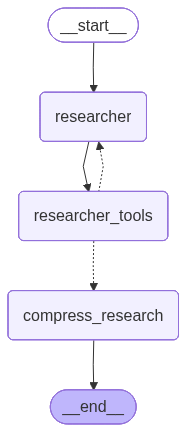

In [57]:
# 构建研究员图
researcher_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

# 添加节点
researcher_builder.add_node("researcher", researcher)
researcher_builder.add_node("researcher_tools", researcher_tools)
researcher_builder.add_node("compress_research", compress_research)

# 添加边缘
researcher_builder.add_edge(START, "researcher")
researcher_builder.add_edge("researcher", "researcher_tools")
# Researcher_tools 使用 Command 路由到 Researcher 或 compress_research
researcher_builder.add_edge("compress_research", END)

# Compile
researcher_graph = researcher_builder.compile()
researcher_graph

### 1.5 运行单个研究人员

让我们用一个简单的查询来测试我们的研究人员。

In [58]:
# 测试研究员
test_query = 'LLM即时工程的最佳实践是什么？'

initial_state = {
    "researcher_messages": [HumanMessage(content=test_query)],
    "research_topic": test_query,
    "tool_call_iterations": 0,
}

result = await researcher_graph.ainvoke(initial_state)

print("=" * 60)
print('研究人员留言历史：')
print("=" * 60)
for message in result["researcher_messages"]:
    message.pretty_print()

print("\n" + "=" * 60)
print('研究结果：')
print("=" * 60)
print(result["compressed_research"])

研究人员留言历史：
================================ Human Message =================================

LLM即时工程的最佳实践是什么？
================================== Ai Message ==================================
Tool Calls:
  think_tool (call_00_yHupmiY599GhcDqsW79p3996)
 Call ID: call_00_yHupmiY599GhcDqsW79p3996
  Args:
    reflection: 用户询问LLM提示工程（Prompt Engineering）的最佳实践。这是一个相对明确的问题，需要搜索相关的最佳实践、技巧和指南。我打算先进行一次全面的搜索，看看有哪些权威来源和关键实践。
================================= Tool Message =================================
Name: think_tool

Reflection recorded: 用户询问LLM提示工程（Prompt Engineering）的最佳实践。这是一个相对明确的问题，需要搜索相关的最佳实践、技巧和指南。我打算先进行一次全面的搜索，看看有哪些权威来源和关键实践。
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_00_LRE7ue64B8nusHj4Vefy5586)
 Call ID: call_00_LRE7ue64B8nusHj4Vefy5586
  Args:
    query: LLM prompt engineering best practices 2026
================================= Tool Message =================================
Name: tavily_search

为“LLM prompt engin

## 第 2 部分：构建 Supervisor 代理

现在我们将构建一个主管代理，它可以将研究并行委托给多个研究人员代理。这将以我们在第 1 部分中创建的研究代理为基础。

 <img src="../../images/research_supervisor.png" style="width: auto; max-height: 500px; border-radius: 8px;">

### 2.1 定义Supervisor状态

我们可以为我们的主管定义单独的状态。这使得它能够跟踪与研究人员不同的项目，防止它被噪音分散注意力。 

我们还定义了一个客户减速器来处理特定的状态键。默认情况下状态更新会覆盖现有值 - 我们定义了一个自定义化简器以允许连接和覆盖行为

In [59]:
def override_reducer(current_value, new_value):
    """允许覆盖状态值的Reducer 函数。"""
    if isinstance(new_value, dict) and new_value.get("type") == "override":
        return new_value.get("value", new_value)
    else:
        return operator.add(current_value, new_value)


class SupervisorState(TypedDict):
    """状态为主管代理。"""

    supervisor_messages: Annotated[list[MessageLikeRepresentation], override_reducer]
    research_brief: str
    notes: Annotated[list[str], override_reducer] = []
    research_iterations: int = 0
    raw_notes: Annotated[list[str], override_reducer] = []

### 2.2 定义监控工具

在多代理系统中，当今协调子代理的最常见方法是将它们称为工具。这使得子代理能够将其上下文与主管的编排隔离开来，从而实现专业化和集中化。

这就像在工具中调用我们的研究人员子代理并将该工具提供给我们的主管一样简单。

In [60]:
@tool(description='将研究任务委托给专门研究人员')
async def ConductResearch(research_topic: str) -> dict:
    """将特定的研究主题委托给研究代理。

    参数：
        Research_topic：子代理的清晰、具体的研究问题"""
    # 实际调用研究员图
    result = await researcher_graph.ainvoke(
        {
            "researcher_messages": [HumanMessage(content=research_topic)],
            "research_topic": research_topic,
            "tool_call_iterations": 0,
        }
    )

    # 直接返回带有压缩研究和原始笔记的字典
    return {
        "compressed_research": result.get("compressed_research", '研究错误'),
        "raw_notes": result.get("raw_notes", []),
    }


@tool(description='表明所有研究已完成')
def ResearchComplete() -> str:
    """当您收集完所有必要的信息后，请调用此方法。"""
    return '研究标记为完成'

### 2.3 定义Supervisor节点

我们将从定义推理节点的提示开始。与研究人员代理一样，推理节点将依赖于使用我们的自定义提示调用 LLM 来确定要调用哪些工具

In [61]:
lead_researcher_prompt = """你是一名研究主管。您的工作是通过调用“ConductResearch”工具进行研究。

<任务>
调用“ConductResearch”工具来委托研究。当您对调查结果感到满意时，请调用“ResearchComplete”。
</任务>

<可用工具>
1. **ConductResearch**：将研究任务委托给专门的子代理
2. **ResearchComplete**：表示研究已完成
3. **think_tool**：用于反思和战略规划

**关键：在调用 ConductResearch 进行计划之前以及之后评估进度之前使用 think_tool。**
</可用工具>

<说明>
像研究经理一样思考：

1. **仔细阅读问题** - 需要哪些具体信息？
2. **决定如何委托** - 可以同时探索多个独立的角度吗？
3. **每次 ConductResearch 通话后，评估** - 我有足够的资金吗？缺少什么？
</说明>

<硬限制>
- **限制工具调用** - 如果找不到正确的源，则在 {max_researcher_iterations} 工具调用后停止
- **每次迭代最大 {max_concurrent_research_units} 并行代理**
</硬限制>

<缩放规则>
**简单查询** - 使用单个子代理
**比较** - 对每个要比较的元素使用子代理
**重要**：致电 ConductResearch 时提供完整的独立说明
</缩放规则>"""

In [62]:
async def supervisor(state: SupervisorState, config):
    """委托研究的主管代理。"""
    lead_researcher_tools = [ConductResearch, ResearchComplete, think_tool]

    research_model = (
        get_model()
        .bind_tools(lead_researcher_tools)
        .with_retry(stop_after_attempt=MAX_STRUCTURED_OUTPUT_RETRIES)
    )

    supervisor_messages = state.get("supervisor_messages", [])
    response = await research_model.ainvoke(supervisor_messages)

    return {
        "supervisor_messages": [response],
        "research_iterations": state.get("research_iterations", 0) + 1,
    }

我们将自定义工具节点实现，以自动使超出预定义使用限制的工具调用失败。像往常一样，该节点将负责执行代理想要调用的工具，并用结果更新状态

In [63]:
def extract_tool_content(messages):
    """从工具调用消息中提取注释。"""
    return [
        tool_msg.content for tool_msg in filter_messages(messages, include_types="tool")
    ]


async def supervisor_tools(
    state: SupervisorState, config
) -> Command[Literal["supervisor", "__end__"]]:
    """执行主管调用的工具。"""
    supervisor_messages = state.get("supervisor_messages", [])
    research_iterations = state.get("research_iterations", 0)
    most_recent_message = supervisor_messages[-1]

    # 检查退出条件
    exceeded_iterations = research_iterations > MAX_RESEARCHER_ITERATIONS
    no_tool_calls = not most_recent_message.tool_calls
    research_complete = any(
        tc["name"] == "ResearchComplete" for tc in most_recent_message.tool_calls
    )

    if exceeded_iterations or no_tool_calls or research_complete:
        return Command(
            goto=END,
            update={
                "notes": extract_tool_content(supervisor_messages),
                "research_brief": state.get("research_brief", ""),
            },
        )

        # 处理工具调用
    all_tool_messages = []
    update_payload = {"supervisor_messages": []}

    # 处理 think_tool
    for tc in most_recent_message.tool_calls:
        if tc["name"] == "think_tool":
            all_tool_messages.append(
                ToolMessage(
                    content=f"Reflection recorded: {tc['args']['reflection']}",
                    name="think_tool",
                    tool_call_id=tc["id"],
                )
            )

            # 处理 ConductResearch - 现在执行实际的工具
    conduct_research_calls = [
        tc for tc in most_recent_message.tool_calls if tc["name"] == "ConductResearch"
    ]

    if conduct_research_calls:
        try:
            allowed_calls = conduct_research_calls[:MAX_CONCURRENT_RESEARCH_UNITS]
            overflow_calls = conduct_research_calls[MAX_CONCURRENT_RESEARCH_UNITS:]

            # 通过调用该工具并行执行研究任务
            research_tasks = [
                ConductResearch.ainvoke(tc["args"]) for tc in allowed_calls
            ]

            # 直接以字典形式获取结果
            tool_results = await asyncio.gather(*research_tasks)

            # 创建带有结果的工具消息
            for observation_dict, tc in zip(tool_results, allowed_calls):
                all_tool_messages.append(
                    ToolMessage(
                        content=observation_dict.get("compressed_research", '研究错误'),
                        name=tc["name"],
                        tool_call_id=tc["id"],
                    )
                )

                # 处理溢出
            for overflow_call in overflow_calls:
                all_tool_messages.append(
                    ToolMessage(
                        content=f"Error: Exceeded max concurrent units ({MAX_CONCURRENT_RESEARCH_UNITS})",
                        name="ConductResearch",
                        tool_call_id=overflow_call["id"],
                    )
                )

                # 聚合原始笔记
            raw_notes_concat = "\n".join(
                ["\n".join(obs.get("raw_notes", [])) for obs in tool_results]
            )

            if raw_notes_concat:
                update_payload["raw_notes"] = [raw_notes_concat]

        except Exception as e:
            return Command(
                goto=END,
                update={
                    "notes": extract_tool_content(supervisor_messages),
                    "research_brief": state.get("research_brief", ""),
                },
            )

    update_payload["supervisor_messages"] = all_tool_messages
    return Command(goto="supervisor", update=update_payload)

### 2.4 定义边并构建监督图

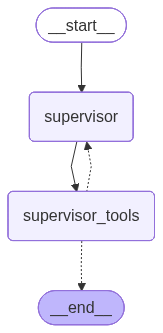

In [64]:
# 构建主管图
supervisor_builder = StateGraph(SupervisorState)
supervisor_builder.add_node("supervisor", supervisor)
supervisor_builder.add_node("supervisor_tools", supervisor_tools)

supervisor_builder.add_edge(START, "supervisor")
supervisor_builder.add_edge("supervisor", "supervisor_tools")
# Supervisor_tools 使用 Command 路由回主管或 END

supervisor_graph = supervisor_builder.compile()
show_graph(supervisor_graph, xray=True)

### 2.5 测试Supervisor

让我们用一个研究问题来考验一下导师吧！

In [ ]:
# 测试主管
research_brief = '推荐一些纽约的中餐馆和印度餐馆'

supervisor_system_prompt = lead_researcher_prompt.format(
    date=get_today_str(),
    max_concurrent_research_units=MAX_CONCURRENT_RESEARCH_UNITS,
    max_researcher_iterations=MAX_RESEARCHER_ITERATIONS,
)

initial_state = {
    "supervisor_messages": [
        SystemMessage(content=supervisor_system_prompt),
        HumanMessage(content=research_brief),
    ],
    "research_brief": research_brief,
    "research_iterations": 0,
    "notes": [],
    "raw_notes": [],
}
result = await supervisor_graph.ainvoke(initial_state)

print("=" * 60)
print('主管留言历史记录：')
print("=" * 60)
for message in result["supervisor_messages"]:
    message.pretty_print()

print("\n" + "=" * 60)
print('收集的研究笔记：')
print("=" * 60)
for i, note in enumerate(result["notes"], 1):
    print(f"\n--- Research Finding {i} ---")
    print(note[:500] + "..." if len(note) > 500 else note)

## 第 3 部分：高级概念（HITL、上下文管理）

这是完全可投入生产的研究代理。我们将在主管周围添加一个工作流程来巩固我们的流程，允许对研究计划进行人工反馈，以及管理上下文的脚手架。

 <img src="../../images/deep_research.png" style="width: auto; max-height: 500px; border-radius: 8px;">

### 3.1 定义主代理状态

现在，我们可以将状态放在一起，以便我们的整体图表进行跟踪。我们可以通过在整体状态中包含相同的键来与主管共享状态。这使得主管能够继承从我们的人类反馈中收集的信息。

In [65]:
class AgentState(TypedDict):
    """State为完全研究代理。"""

    messages: Annotated[list[MessageLikeRepresentation], override_reducer]  # 用户对话
    need_elaboration: bool  # 是否需要要求澄清
    research_brief: str  # 已处理的研究目标
    supervisor_messages: Annotated[
        list[MessageLikeRepresentation], override_reducer
    ]  # 主管谈话
    research_iterations: int  # 跟踪迭代
    notes: Annotated[list[str], override_reducer] = []  # 收集的调查结果
    raw_notes: Annotated[list[str], override_reducer] = []  # 原始笔记
    final_report: str  # 生成的报告


class AgentInputState(TypedDict):
    """代理的输入 - 只是用户消息。"""

    messages: list

### 3.2 在循环中添加人类

该节点使用 `interrupt()` 注入有关研究主题的人类反馈。

In [66]:
class ClarifyWithUser(BaseModel):
    """用于澄清的结构化输出。"""

    need_clarification: bool = Field(description="是否需要向用户提出澄清问题。")
    question: str = Field(description="用于澄清研究范围的用户问题。")
    verification: str = Field(description="无需澄清时返回给用户的确认消息。")


clarify_with_user_instructions = """这些是迄今为止交换的消息：
<消息>
 {messages} 
</消息>

今天的日期是 {date} 。

评估您是否需要提出澄清问题。

如果您需要提问：
- 收集必要信息时要简洁
- 不要询问已经提供的信息

使用以下键以 JSON 形式响应：
{ {"need_clarification": boolean, "question": "...", "verification": "..."} }

如果需要澄清：
{ {"need_clarification": true, "question": "<your question>", "verification": ""} }

如果不需要澄清：
{{"need_clarification": false, "question": "", "verification": "<确认消息>"}}"""


async def clarify_with_user(state: AgentState, config):
    """如果需要，可以使用“人机交互”来提出澄清问题。"""
    messages = state["messages"]

    # 配置模型以进行结构化澄清
    clarification_model = (
        get_model()
        .with_structured_output(ClarifyWithUser)
        .with_retry(stop_after_attempt=MAX_STRUCTURED_OUTPUT_RETRIES)
    )

    # 分析是否需要澄清
    prompt_content = clarify_with_user_instructions.format(
        messages=get_buffer_string(messages), date=get_today_str()
    )
    response = await clarification_model.ainvoke([HumanMessage(content=prompt_content)])

    # 如果需要澄清，请使用中断来暂停用户输入
    if response.need_clarification:
        return {
            "messages": [AIMessage(content=response.question)],
            "need_elaboration": True,
        }
    else:
        # 无需澄清
        return {
            "messages": [AIMessage(content=response.verification)],
            "need_elaboration": False,
        }

In [67]:
async def human_input(state: AgentState, config):
    ai_question = state["messages"][-1].content
    user_response = interrupt(ai_question)
    return {
        "messages": [HumanMessage(content=user_response)],
        "need_elaboration": False,
    }

接下来，我们将创建另一个节点来获取研究主题和人类反馈。 

该节点将负责生成高级计划。通过国家重点研究简报向我们的代理人提供此计划将使我们的代理人即使在执行复杂的任务时也能保持在正轨上。

In [ ]:
class ResearchQuestion(BaseModel):
    """结构化研究问题。"""

    research_brief: str = Field(description="用于指导后续研究的完整研究简报。")


create_research_brief_prompt = """将这些消息转化为详细的研究问题：

<消息>
 {messages} 
</消息>

今天的日期是 {date} 。

指南：
1. 最大化特异性和细节 - 包括所有用户偏好
2. 填写未说明但必要的开放式维度
3. 避免无根据的假设
4. 使用第一人称（从用户的角度）
5. 对于产品/旅行研究，优先选择官方来源"""


async def write_research_brief(
    state: AgentState, config
) -> Command[Literal["research_supervisor"]]:
    """将用户消息转换为结构化的研究简介。"""
    # 配置结构化输出模型
    research_model = (
        get_model()
        .with_structured_output(ResearchQuestion)
        .with_retry(stop_after_attempt=MAX_STRUCTURED_OUTPUT_RETRIES)
    )

    # 生成研究简介
    prompt_content = create_research_brief_prompt.format(
        messages=get_buffer_string(state.get("messages", [])), date=get_today_str()
    )
    response = await research_model.ainvoke([HumanMessage(content=prompt_content)])

    # 初始化主管
    supervisor_system_prompt = lead_researcher_prompt.format(
        date=get_today_str(),
        max_concurrent_research_units=MAX_CONCURRENT_RESEARCH_UNITS,
        max_researcher_iterations=MAX_RESEARCHER_ITERATIONS,
    )

    return {
        "research_brief": response.research_brief,
        "supervisor_messages": {
            "type": "override",
            "value": [
                SystemMessage(content=supervisor_system_prompt),
                HumanMessage(content=response.research_brief),
            ],
        },
    }

### 3.3 格式输出

In [ ]:
final_report_generation_prompt = """根据进行的所有研究，针对以下问题创建全面的答案：
<研究简介>
 {research_brief} 
</研究简介>

今天的日期是 {date} 。

以下是调查结果：
<调查结果>
 {findings} 
</调查结果>

创建一个详细的答案：
1. 组织良好，标题正确（# 为标题，## 为章节）
2. 包括研究中的具体事实
3.使用[Title](URL)格式的参考文献
4. 提供全面的分析
5. 最后包含“来源”部分

适当地构建您的报告：
- 比较：介绍→概述A→概述B→比较→结论
- 对于列表：仅包含详细信息的列表
- 总结：概述→关键概念→结论

使用 ## 作为章节标题。彻底——用户期望进行深入的研究。"""


async def final_report_generation(state: AgentState, config):
    """生成最终的综合研究报告。"""
    notes = state.get("notes", [])
    findings = "\n".join(notes)

    # 创建报告提示
    final_report_prompt = final_report_generation_prompt.format(
        research_brief=state.get("research_brief", ""),
        messages=get_buffer_string(state.get("messages", [])),
        findings=findings,
        date=get_today_str(),
    )

    # 生成报告
    final_report = await get_model().ainvoke(
        [HumanMessage(content=final_report_prompt)]
    )

    return {
        "final_report": final_report.content,
        "messages": [final_report],
        "notes": {"type": "override", "value": []},
    }

### 3.4 定义边缘并持久化编译

我们现在可以使用边缘将整个工作流程组合在一起！请注意，研究主管已被添加为该工作流程中的一个节点，演示了如何将子图创建为单个节点。

我们还使用检查点编译我们的代理，这使得 LangGraph 能够内置持久性。这使我们的代理能够记住之前的对话，并在节点发生故障时回滚执行

In [ ]:
def human_feedback_needed(state: AgentState):
    need_elaboration = state.get("need_elaboration", False)
    if need_elaboration:
        return "human_input"
    else:
        return "write_research_brief"

In [ ]:
# 创建持久性检查点
checkpointer = MemorySaver()

# 建立完整的研究工作流程
deep_researcher_builder = StateGraph(AgentState, input_schema=AgentInputState)

# 添加节点
deep_researcher_builder.add_node("clarify_with_user", clarify_with_user)
deep_researcher_builder.add_node("human_input", human_input)
deep_researcher_builder.add_node("write_research_brief", write_research_brief)
deep_researcher_builder.add_node("research_supervisor", supervisor_graph)
deep_researcher_builder.add_node("final_report_generation", final_report_generation)

# 添加边缘
deep_researcher_builder.add_edge(START, "clarify_with_user")
deep_researcher_builder.add_conditional_edges(
    "clarify_with_user",
    human_feedback_needed,
    {
        "human_input": "human_input",
        "write_research_brief": "write_research_brief",
    },
)
deep_researcher_builder.add_edge("human_input", "clarify_with_user")
deep_researcher_builder.add_edge("write_research_brief", "research_supervisor")
deep_researcher_builder.add_edge("research_supervisor", "final_report_generation")
deep_researcher_builder.add_edge("final_report_generation", END)

# 使用检查指针进行编译以支持中断/恢复
deep_research_graph = deep_researcher_builder.compile(checkpointer=checkpointer)
show_graph(deep_research_graph, xray=True)

### 3.5 测试HITL和持久性

让我们测试完整的研究工作流程！我们将首先向代理提供一个模糊的查询，这应该会触发我们的代理要求澄清信息。

In [ ]:
# 测试完整的工作流程
import uuid

test_query = '推荐曼哈顿最好的中餐馆'

initial_state = {"messages": [HumanMessage(content=test_query)]}

# 使用 thread_id 创建配置以进行检查点
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

# 第一次调用 - 如果需要澄清，将在中断时暂停
print('开始研究工作流程...')
result = await deep_research_graph.ainvoke(initial_state, config=config)

# 检查我们是否遇到中断
if "__interrupt__" in result:
    print("\n" + "=" * 60)
    print('中断：检测到澄清问题')
    print("=" * 60)

    # 获取状态查看中断详情
    state_snapshot = deep_research_graph.get_state(config)

    # 显示中断值（澄清问题）
    if hasattr(state_snapshot, 'tasks') and state_snapshot.tasks:
        for task in state_snapshot.tasks:
            if hasattr(task, 'interrupts') and task.interrupts:
                for interrupt_info in task.interrupts:
                    print(f"Question: {interrupt_info.value}")

此时，我们的代理在执行过程中暂停，等待人类反馈！要从暂停的执行中恢复，我们可以使用在图形实现中使用的相同 Command 对象。

In [ ]:
# 通过我们的响应从中断中恢复
result = await deep_research_graph.ainvoke(
    Command(resume='没有偏好。运用你最好的判断，不要再问任何问题。'), config=config
)

print("\n" + "=" * 60)
print('最终研究报告：')
print("=" * 60)
print(result["final_report"])